# Visualization

This notebook reproduces all figures presented in the paper using the
generated experimental results.

The notebook assumes that the following notebooks have already been run:

1. anonymization.ipynb
2. utility_evaluation.ipynb
3. mutual_information.ipynb
4. template_inversion.ipynb

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.linewidth"] = 1.2

In [2]:
DATA_DIR = Path("../data")
RESULT_DIR = DATA_DIR / "results"
FIGURE_DIR = DATA_DIR / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
utility = pd.read_csv(RESULT_DIR / "utility_results.csv")
mi = pd.read_csv(RESULT_DIR / "mutual_information.csv")
inversion = pd.read_csv(RESULT_DIR /  "template_inversion" / "summary.csv")

display(utility.head())
display(mi.head())
display(inversion.head())

,algorithm,cluster_k,neighbor_k,semantic_consistency,retrieval_consistency
0,MDAV-C,5,100,0.877192,0.433230
1,MDAV-C,5,200,0.877192,0.521080
2,MDAV-C,5,300,0.877192,0.588360
3,MDAV-C,5,400,0.877192,0.649027
4,MDAV-C,5,500,0.877192,0.707102


,algorithm,cluster_k,mi,mi_sigma
0,MDAV-C,5,27.385625,27.609277
1,MDAV-C,10,20.268695,20.813159
2,MDAV-C,25,12.733525,12.846216
3,MDAV-C,50,7.975684,8.703833
4,MDAV-C,100,6.021649,6.703552


,label,bleu,bertscore_f1
0,Baseline,2.475401,0.585424
1,MDAV-C-k5,2.568397,0.583106
2,MDAV-C-k10,2.904097,0.586482
3,MDAV-C-k25,2.561052,0.583205
4,MDAV-C-k50,2.792898,0.585332


In [4]:
results = (utility.merge(mi,on=["algorithm","cluster_k"]))

display(results)

,algorithm,cluster_k,neighbor_k,semantic_consistency,retrieval_consistency,mi,mi_sigma
0,MDAV-C,5,100,0.877192,0.433230,27.385625,27.609277
1,MDAV-C,5,200,0.877192,0.521080,27.385625,27.609277
2,MDAV-C,5,300,0.877192,0.588360,27.385625,27.609277
3,MDAV-C,5,400,0.877192,0.649027,27.385625,27.609277
4,MDAV-C,5,500,0.877192,0.707102,27.385625,27.609277
5,MDAV-C,10,100,0.841316,0.333950,20.268695,20.813159
6,MDAV-C,10,200,0.841316,0.430595,20.268695,20.813159
7,MDAV-C,10,300,0.841316,0.508677,20.268695,20.813159
8,MDAV-C,10,400,0.841316,0.579348,20.268695,20.813159
9,MDAV-C,10,500,0.841316,0.648000,20.268695,20.813159


In [5]:
def format_axes(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(width=2, length=6)
    plt.grid(False)
    plt.tight_layout()

In [6]:
pivot = utility.pivot_table(
    index="cluster_k",
    columns=[
        "algorithm",
        "neighbor_k"
    ],
    values="retrieval_consistency"
)

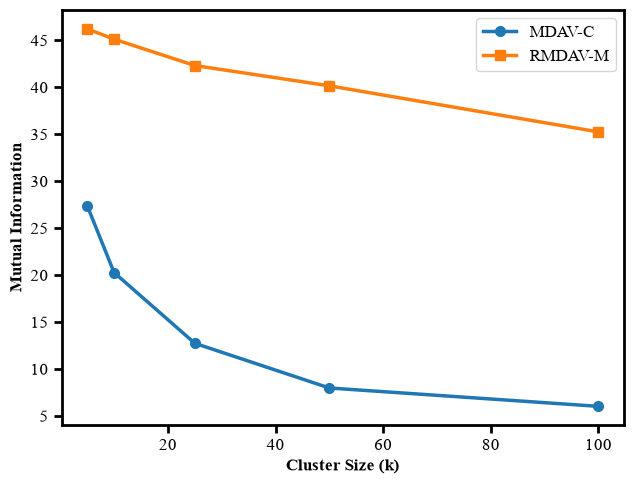

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for algorithm, marker in zip(["MDAV-C", "RMDAV-M"], ["o", "s"],):
    subset = mi[
        mi["algorithm"] == algorithm
    ].sort_values("cluster_k")
    ax.plot(
        subset["cluster_k"],
        subset["mi"],
        marker=marker,
        linewidth=2.5,
        markersize=7,
        label=algorithm,
    )
ax.set_xlabel(
    "Cluster Size (k)",
    fontweight="bold",
)
ax.set_ylabel(
    "Mutual Information",
    fontweight="bold",
)
ax.legend()
format_axes(ax)

plt.savefig(
    FIGURE_DIR /
    "mutual_information.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR /
    "mutual_information.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

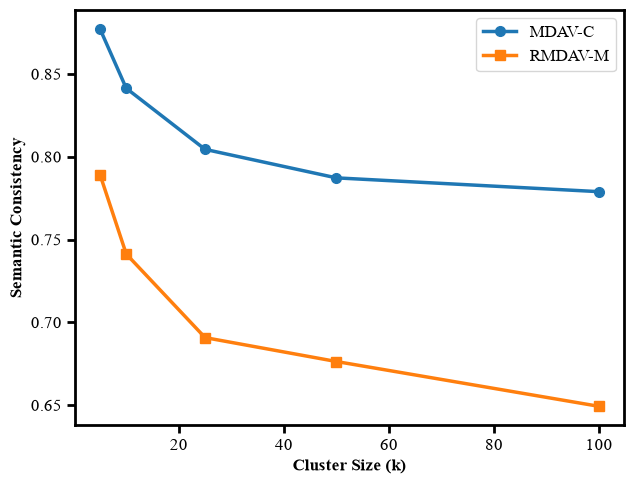

In [8]:
fig, ax = plt.subplots(figsize=(6.5,5))

for algorithm, marker in zip(["MDAV-C","RMDAV-M"],["o","s"],):

    subset = (
        utility[
            utility["algorithm"] == algorithm
        ]
        .drop_duplicates("cluster_k")
        .sort_values("cluster_k")
    )

    ax.plot(
        subset["cluster_k"],
        subset["semantic_consistency"],
        marker=marker,
        linewidth=2.5,
        markersize=7,
        label=algorithm,
    )

ax.set_xlabel(
    "Cluster Size (k)",
    fontweight="bold",
)

ax.set_ylabel(
    "Semantic Consistency",
    fontweight="bold",
)

ax.legend()

format_axes(ax)

plt.savefig(
    FIGURE_DIR /
    "semantic_consistency.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR /
    "semantic_consistency.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [9]:
neighbor_values = sorted(utility["neighbor_k"].unique())

print("Neighbourhood sizes:", neighbor_values,)

Neighbourhood sizes: [np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500)]


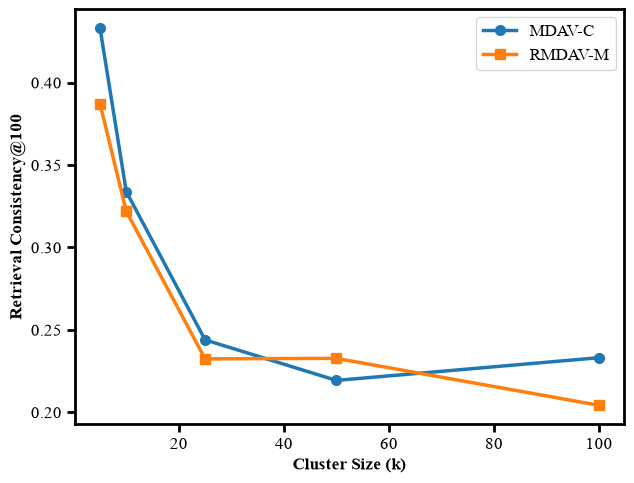

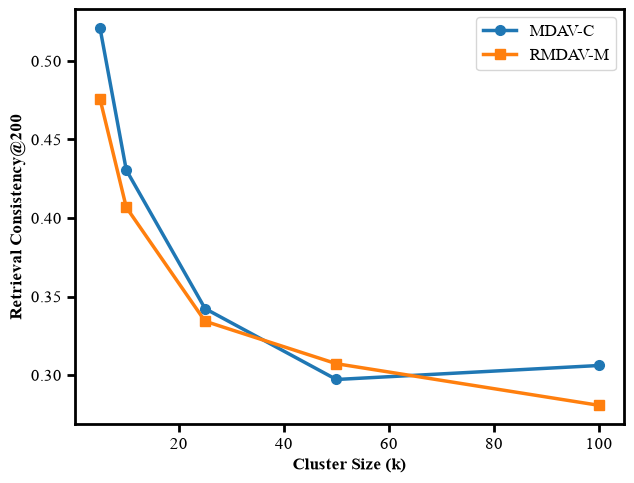

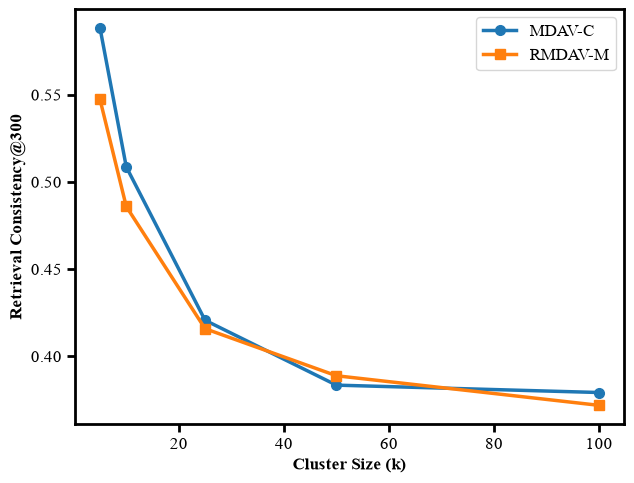

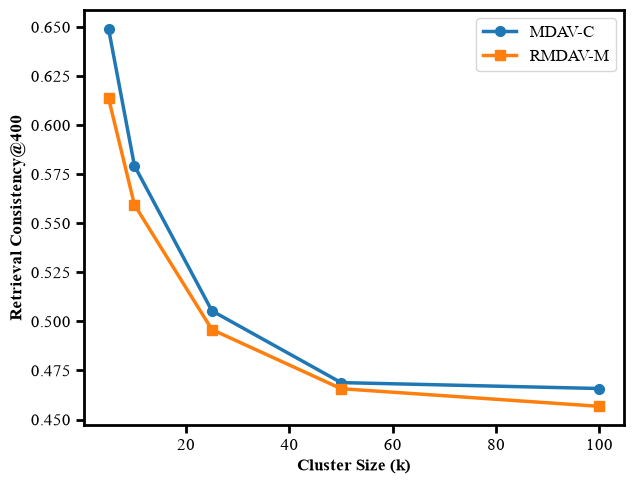

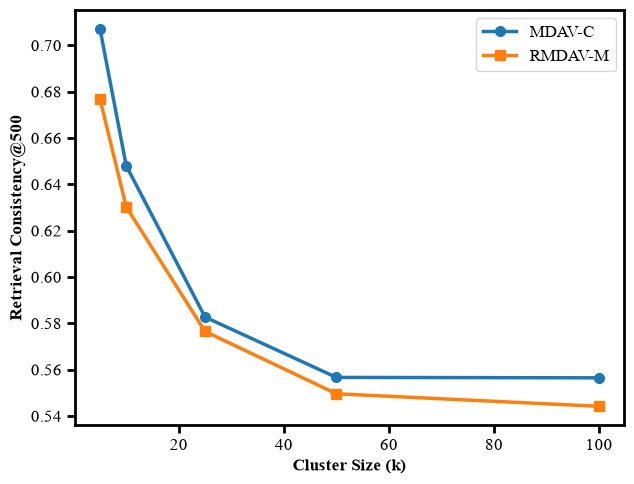

In [11]:
for neighbor_k in neighbor_values:

    fig, ax = plt.subplots(figsize=(6.5,5))

    for algorithm, marker in zip(
        ["MDAV-C", "RMDAV-M"],
        ["o", "s"],
    ):

        subset = (
            utility[
                (utility["algorithm"] == algorithm)
                &
                (utility["neighbor_k"] == neighbor_k)
            ]
            .sort_values("cluster_k")
        )

        ax.plot(
            subset["cluster_k"],
            subset["retrieval_consistency"],
            marker=marker,
            linewidth=2.5,
            markersize=7,
            label=algorithm,
        )

    ax.set_xlabel(
        "Cluster Size (k)",
        fontweight="bold",
    )

    ax.set_ylabel(
        f"Retrieval Consistency@{neighbor_k}",
        fontweight="bold",
    )

    ax.legend()

    format_axes(ax)

    plt.savefig(
        FIGURE_DIR /
        f"retrieval_{neighbor_k}.pdf",
        dpi=300,
        bbox_inches="tight",
    )

    plt.savefig(
        FIGURE_DIR /
        f"retrieval_{neighbor_k}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

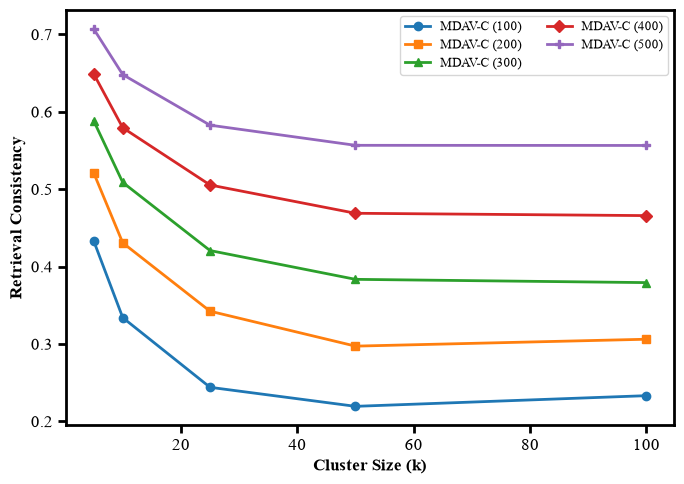

In [12]:
fig, ax = plt.subplots(figsize=(7,5))

markers = {
    100: "o",
    200: "s",
    300: "^",
    400: "D",
    500: "P",
}

for neighbor_k in neighbor_values:

    subset = (
        utility[
            (utility["algorithm"]=="MDAV-C")
            &
            (utility["neighbor_k"]==neighbor_k)
        ]
        .sort_values("cluster_k")
    )

    ax.plot(
        subset["cluster_k"],
        subset["retrieval_consistency"],
        marker=markers[neighbor_k],
        linewidth=2,
        label=f"MDAV-C ({neighbor_k})",
    )

ax.set_xlabel(
    "Cluster Size (k)",
    fontweight="bold",
)

ax.set_ylabel(
    "Retrieval Consistency",
    fontweight="bold",
)

ax.legend(
    fontsize=9,
    ncol=2,
)

format_axes(ax)

plt.savefig(
    FIGURE_DIR /
    "retrieval_mdav.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR /
    "retrieval_mdav.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

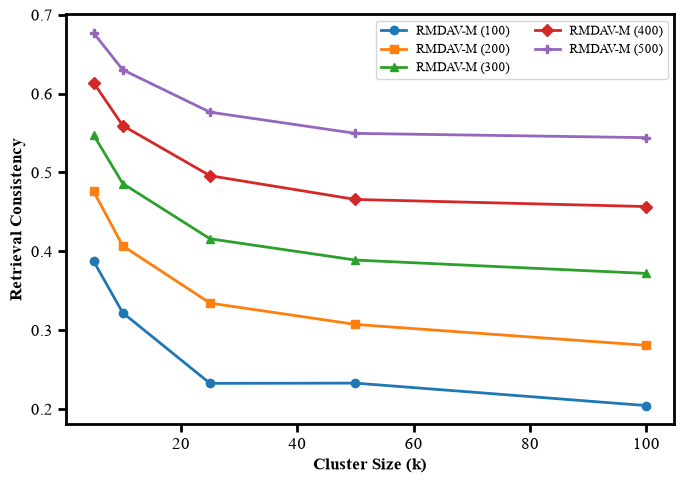

In [13]:
fig, ax = plt.subplots(figsize=(7,5))

markers = {
    100: "o",
    200: "s",
    300: "^",
    400: "D",
    500: "P",
}

for neighbor_k in neighbor_values:

    subset = (
        utility[
            (utility["algorithm"]=="RMDAV-M")
            &
            (utility["neighbor_k"]==neighbor_k)
        ]
        .sort_values("cluster_k")
    )

    ax.plot(
        subset["cluster_k"],
        subset["retrieval_consistency"],
        marker=markers[neighbor_k],
        linewidth=2,
        label=f"RMDAV-M ({neighbor_k})",
    )

ax.set_xlabel(
    "Cluster Size (k)",
    fontweight="bold",
)

ax.set_ylabel(
    "Retrieval Consistency",
    fontweight="bold",
)

ax.legend(
    fontsize=9,
    ncol=2,
)

format_axes(ax)

plt.savefig(
    FIGURE_DIR /
    "retrieval_rmdav.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR /
    "retrieval_rmdav.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [14]:
retrieval_summary = (
    utility
    .pivot_table(
        index=["algorithm", "cluster_k"],
        columns="neighbor_k",
        values="retrieval_consistency",
    )
    .round(4)
)

display(retrieval_summary)

neighbor_k              100     200     300     400     500
algorithm cluster_k                                        
MDAV-C    5          0.4332  0.5211  0.5884  0.6490  0.7071
          10         0.3339  0.4306  0.5087  0.5793  0.6480
          25         0.2440  0.3423  0.4207  0.5054  0.5827
          50         0.2194  0.2972  0.3835  0.4688  0.5566
          100        0.2332  0.3061  0.3792  0.4658  0.5565
RMDAV-M   5          0.3873  0.4759  0.5473  0.6137  0.6768
          10         0.3220  0.4068  0.4859  0.5595  0.6302
          25         0.2324  0.3343  0.4159  0.4958  0.5765
          50         0.2328  0.3072  0.3889  0.4657  0.5496
          100        0.2042  0.2807  0.3719  0.4567  0.5442

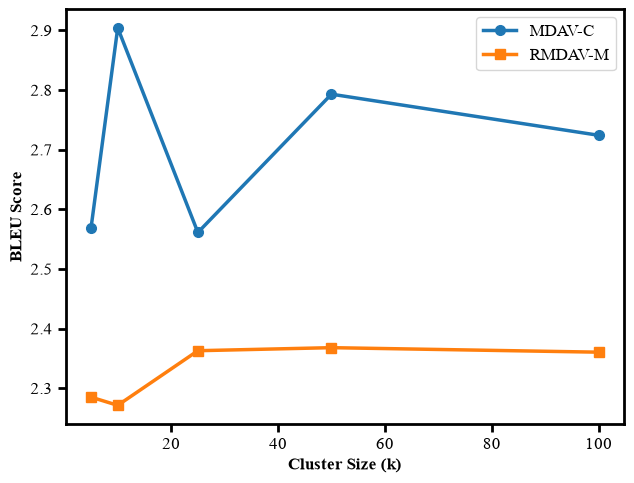

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 5))

for algorithm, marker in zip(["MDAV-C", "RMDAV-M"],["o", "s"],):

    subset = (
        inversion[
            inversion["label"].str.contains(algorithm)
        ]
        .copy()
    )

    subset["cluster_k"] = (
        subset["label"]
        .str.extract(r"k(\d+)")
        .astype(int)
    )

    subset = subset.sort_values("cluster_k")

    ax.plot(
        subset["cluster_k"],
        subset["bleu"],
        marker=marker,
        linewidth=2.5,
        markersize=7,
        label=algorithm,
    )

ax.set_xlabel(
    "Cluster Size (k)",
    fontweight="bold",
)

ax.set_ylabel(
    "BLEU Score",
    fontweight="bold",
)

ax.legend()

format_axes(ax)

plt.savefig(
    FIGURE_DIR / "bleu.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "bleu.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

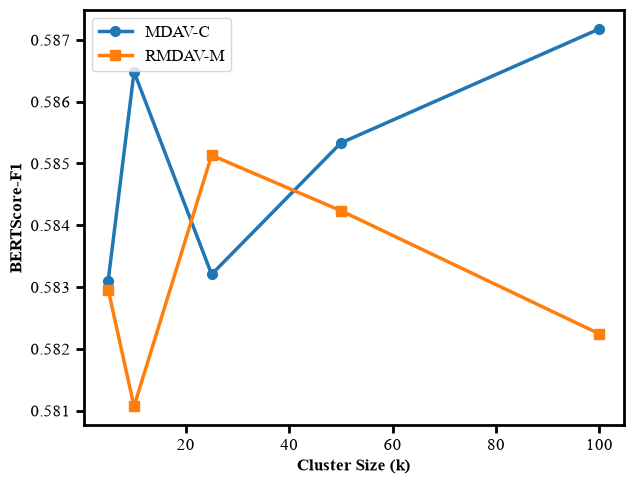

In [16]:
fig, ax = plt.subplots(figsize=(6.5,5))

for algorithm, marker in zip(["MDAV-C", "RMDAV-M"],["o","s"],):

    subset = (
        inversion[
            inversion["label"].str.contains(algorithm)
        ]
        .copy()
    )

    subset["cluster_k"] = (
        subset["label"]
        .str.extract(r"k(\d+)")
        .astype(int)
    )

    subset = subset.sort_values("cluster_k")

    ax.plot(
        subset["cluster_k"],
        subset["bertscore_f1"],
        marker=marker,
        linewidth=2.5,
        markersize=7,
        label=algorithm,
    )

ax.set_xlabel(
    "Cluster Size (k)",
    fontweight="bold",
)

ax.set_ylabel(
    "BERTScore-F1",
    fontweight="bold",
)

ax.legend()

format_axes(ax)

plt.savefig(
    FIGURE_DIR / "bertscore.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "bertscore.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [17]:
tradeoff = results.copy()

tradeoff["privacy"] = (
    tradeoff.groupby("algorithm")["mi"]
    .transform(
        lambda x:
        (x.max() - x) /
        (x.max() - x.min())
    )
)

tradeoff["semantic"] = (
    tradeoff.groupby("algorithm")["semantic_consistency"]
    .transform(
        lambda x:
        (x - x.min()) /
        (x.max() - x.min())
    )
)

tradeoff["retrieval"] = (
    tradeoff.groupby(
        ["algorithm", "neighbor_k"]
    )["retrieval_consistency"]
    .transform(
        lambda x:
        (x - x.min()) /
        (x.max() - x.min())
    )
)

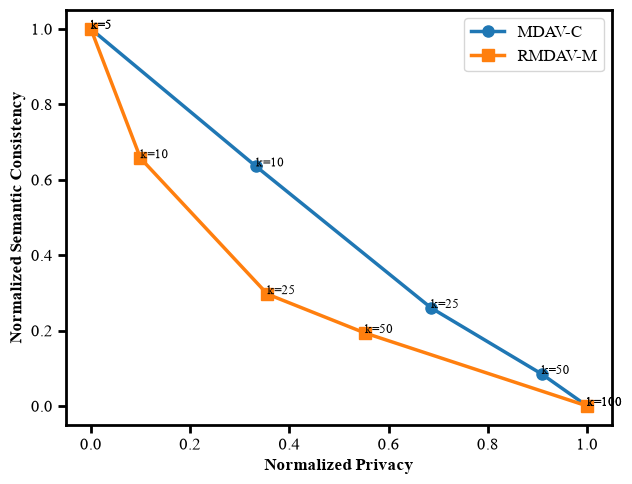

In [18]:
fig, ax = plt.subplots(figsize=(6.5,5))

for algorithm, marker in zip(
    ["MDAV-C","RMDAV-M"],
    ["o","s"],
):

    subset = (
        tradeoff[
            tradeoff["algorithm"]==algorithm
        ]
        .drop_duplicates("cluster_k")
        .sort_values("cluster_k")
    )

    ax.plot(
        subset["privacy"],
        subset["semantic"],
        marker=marker,
        linewidth=2.5,
        markersize=8,
        label=algorithm,
    )

    for _, row in subset.iterrows():

        ax.text(
            row["privacy"],
            row["semantic"],
            f"k={row['cluster_k']}",
            fontsize=9,
        )

ax.set_xlabel(
    "Normalized Privacy",
    fontweight="bold",
)

ax.set_ylabel(
    "Normalized Semantic Consistency",
    fontweight="bold",
)

ax.legend()

format_axes(ax)

plt.savefig(
    FIGURE_DIR / "privacy_semantic.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "privacy_semantic.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

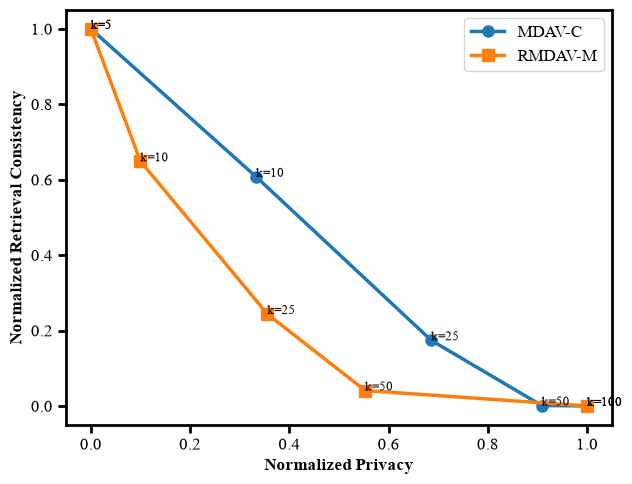

In [19]:
neighbor = 500

fig, ax = plt.subplots(figsize=(6.5,5))

for algorithm, marker in zip(["MDAV-C","RMDAV-M"],["o","s"],):

    subset = (
        tradeoff[
            (tradeoff["algorithm"]==algorithm)
            &
            (tradeoff["neighbor_k"]==neighbor)
        ]
        .sort_values("cluster_k")
    )

    ax.plot(
        subset["privacy"],
        subset["retrieval"],
        marker=marker,
        linewidth=2.5,
        markersize=8,
        label=algorithm,
    )

    for _, row in subset.iterrows():

        ax.text(
            row["privacy"],
            row["retrieval"],
            f"k={row['cluster_k']}",
            fontsize=9,
        )

ax.set_xlabel(
    "Normalized Privacy",
    fontweight="bold",
)

ax.set_ylabel(
    "Normalized Retrieval Consistency",
    fontweight="bold",
)

ax.legend()

format_axes(ax)

plt.savefig(
    FIGURE_DIR / "privacy_retrieval.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "privacy_retrieval.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()